# Portfolio Optimization Library Comparison

**Docker image**: `ml4t`

This notebook compares PyPortfolioOpt, Riskfolio-Lib, and skfolio on one training
panel, then evaluates their frozen allocations on later observations.

**Learning Objectives**:
- Fit comparable mean-risk allocators through three library APIs
- Keep walk-forward model assessment inside the training window
- Compare frozen test-period risk, return, and concentration
- Reconcile a vectorized allocation with execution-aware daily targets

**Book Reference**: Chapter 17, Section 17.7 (Comparing allocator performance)

**Prerequisites**: `02_mean_variance_optimization`, `03_robust_optimization`

## Library Overview

| Library | Role in this notebook | Interface used |
|---------|-----------------------|----------------|
| **PyPortfolioOpt** | Classical, tail-risk, HRP, and penalized allocations | Optimizer objects |
| **Riskfolio-Lib** | Multiple risk measures and risk parity | Portfolio object |
| **skfolio** | Mean-risk, HRP, and walk-forward assessment | sklearn-style estimators |

The comparison concerns the versions pinned by the `ml4t` image. Package breadth and
release cadence can change independently of the methods demonstrated here.

## Imports & Settings

### cvxpy Compatibility Check

Riskfolio-Lib relies on a small set of cvxpy internals. Surface a clear error early
if the installed cvxpy is incompatible, rather than failing deep inside an optimizer.

In [1]:
"""Compare three portfolio libraries with train-only fitting and later evaluation."""

import warnings
from contextlib import contextmanager
from unittest.mock import patch

import cvxpy as cp
import cvxpy.reductions.matrix_stuffing as cvxpy_matrix_stuffing
from cvxpy.problems.problem import Problem as _CvxpyProblem

missing_cvxpy_symbols = [
    name
    for name in ("extract_lower_bounds", "extract_upper_bounds")
    if not hasattr(cvxpy_matrix_stuffing, name)
]
if not hasattr(_CvxpyProblem, "_supports_cpp"):
    missing_cvxpy_symbols.append("Problem._supports_cpp")
if missing_cvxpy_symbols:
    raise RuntimeError(
        "Incompatible cvxpy runtime for the Riskfolio-Lib comparison notebook. "
        "Install the supported cvxpy stack instead of patching site-packages at runtime. "
        f"Missing symbols: {missing_cvxpy_symbols}"
    )

### Third-Party Imports

In [2]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
import riskfolio as rp
from IPython.display import Markdown, display
from ml4t.backtest import (
    BacktestConfig,
    CommissionType,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.config import SlippageType
from ml4t.backtest.execution.rebalancer import RebalanceConfig, TargetWeightExecutor
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from plotly.subplots import make_subplots
from pypfopt import (
    EfficientCVaR,
    EfficientFrontier,
    HRPOpt,
    objective_functions,
    risk_models,
)
from scipy.optimize import linprog, minimize
from skfolio import RiskMeasure
from skfolio.cluster import HierarchicalClustering, LinkageMethod
from skfolio.distance import PearsonDistance
from skfolio.model_selection import WalkForward
from skfolio.moments import EmpiricalCovariance, EmpiricalMu
from skfolio.optimization import HierarchicalRiskParity, MeanRisk, ObjectiveFunction
from skfolio.prior import EmpiricalPrior
from sklearn.base import clone

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_palette, show_plotly_with_alt

In [3]:
# Production defaults - Papermill overrides for CI testing
MAX_SYMBOLS = 0  # 0 = all
SEED = 42
TRAIN_END = "2021-12-31"
TRADING_DAYS = 252
RISK_FREE_RATE = 0.04
CVAR_CONFIDENCE = 0.95
FRONTIER_POINTS = 50
COMMISSION_RATE = 0.0005
SLIPPAGE_RATE = 0.0005
TRANSACTION_COST_PENALTY = 0.01
L2_GAMMA = 0.5
ACTIVE_WEIGHT_THRESHOLD = 0.001
WEIGHT_TOLERANCE = 1e-5
COMMON_WEIGHT_TOLERANCE = 5e-4
COMMON_OBJECTIVE_TOLERANCE = 1e-7
MAX_SHARPE_EXCESS_TOLERANCE = 1e-12
INFEASIBLE_MAX_SHARPE_POLICY = "cash"

# All common moments are arithmetic daily estimates. Dividing the annual hurdle by
# the annualization factor preserves exactly the same linear excess-return objective.
RISK_FREE_RATE_DAILY = RISK_FREE_RATE / TRADING_DAYS

In [4]:
set_global_seeds(SEED)

## Load Data

All three libraries are fitted on the same training rows and scored on the same later ones,
so any difference between them is the method or its defaults rather than the data.

### The universe, and where the training window ends

In [5]:
# Fixed teaching universe diversified across asset classes
_FULL_UNIVERSE = [
    "SPY",
    "QQQ",
    "IWM",
    "EFA",
    "EEM",  # Equities
    "AGG",
    "TLT",
    "LQD",  # Fixed Income
    "GLD",
    "VNQ",
    "DBC",  # Alternatives
]
# Configuration
SYMBOLS = _FULL_UNIVERSE[:MAX_SYMBOLS] if MAX_SYMBOLS else _FULL_UNIVERSE
START_DATE = "2018-01-01"
END_DATE = "2024-12-01"

### Reading the panel

In [6]:
etf_data = load_etfs(symbols=SYMBOLS, start_date=START_DATE, end_date=END_DATE).sort(
    ["timestamp", "symbol"]
)
print(f"Loaded {etf_data.height:,} rows for {len(SYMBOLS)} fixed teaching ETFs")

Loaded 19,140 rows for 11 fixed teaching ETFs


### One column per fund, one row per session

Every library takes its inputs in this shape: an asset-by-time matrix of returns, from which
the moments are estimated. Getting there is the last step the three have in common.

In [7]:
# Prepare the canonical panel in Polars before crossing into pandas-native optimizer APIs.
prices_wide = (
    etf_data.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .fill_null(strategy="forward")
    .drop_nulls()
)
prices = prices_wide.to_pandas().set_index("timestamp")

returns = prices.pct_change().dropna()
tickers = prices.columns.tolist()
num_stocks = len(tickers)
train_prices = prices.loc[:TRAIN_END]
train_returns = returns.loc[:TRAIN_END]
test_returns = returns.loc[returns.index > TRAIN_END]

if train_returns.empty or test_returns.empty:
    raise RuntimeError("The declared training and test windows must both contain returns.")

print(
    f"Training: {train_returns.index.min().date()} to {train_returns.index.max().date()} "
    f"({len(train_returns):,} returns)"
)
print(
    f"Test: {test_returns.index.min().date()} to {test_returns.index.max().date()} "
    f"({len(test_returns):,} returns)"
)

Training: 2018-01-03 to 2021-12-31 (1,007 returns)
Test: 2022-01-03 to 2024-11-29 (732 returns)


The fixed list is a teaching universe, not a point-in-time index reconstruction. Every
allocator sees the same training rows, arithmetic sample moments, and economic hurdle.

In [8]:
display(
    Markdown(
        f"All Max-Sharpe optimizers use an annual risk-free hurdle of "
        f"**{RISK_FREE_RATE:.1%}**. The daily APIs receive "
        f"**{RISK_FREE_RATE_DAILY:.6%}** under the same arithmetic annualization contract."
    )
)

All Max-Sharpe optimizers use an annual risk-free hurdle of **4.0%**. The daily APIs receive **0.015873%** under the same arithmetic annualization contract.

## Part 1: PyPortfolioOpt

PyPortfolioOpt is the most accessible library with good defaults.

Every library returns weights in a different container. Aligning them by symbol before
evaluation prevents silent column-order errors and makes the allocation contract explicit.

In [9]:
def align_weights(weights, name: str) -> pd.Series:
    """Align a library weight result to the canonical symbol order and validate it."""
    if isinstance(weights, pd.Series):
        aligned = weights.reindex(tickers).fillna(0.0).astype(float)
    elif isinstance(weights, dict):
        aligned = pd.Series(weights, dtype=float).reindex(tickers).fillna(0.0)
    else:
        aligned = pd.Series(np.asarray(weights, dtype=float), index=tickers)

    if not np.isfinite(aligned).all():
        raise RuntimeError(f"{name} returned non-finite weights.")
    if (aligned < -WEIGHT_TOLERANCE).any():
        raise RuntimeError(f"{name} violates the declared long-only bounds.")
    if not np.isclose(aligned.sum(), 1.0, atol=WEIGHT_TOLERANCE):
        raise RuntimeError(f"{name} weights sum to {aligned.sum():.8f}, not one.")
    return aligned

Solver wrappers keep diagnostics visible. Only the two pinned-library warnings named below are
scoped to their responsible calls; exposed optimizer problems must report exact optimal status.

In [10]:
def assert_optimal_status(problem: cp.Problem, name: str) -> None:
    """Require an exact optimal status from an exposed cvxpy problem."""
    if problem.status != cp.OPTIMAL:
        raise RuntimeError(f"{name} solver status is {problem.status!r}, not {cp.OPTIMAL!r}.")


CVXPY_STAR_WARNING_PATTERN = (
    r"(?s)\A\s*This use of ``\*`` has resulted in matrix multiplication\.\n"
    r"Using ``\*`` for matrix multiplication has been deprecated since CVXPY 1\.1\.\n"
    r"    Use ``\*`` for matrix-scalar and vector-scalar multiplication\.\n"
    r"    Use ``@`` for matrix-matrix and matrix-vector multiplication\.\n"
    r"    Use ``multiply`` for elementwise multiplication\.\n"
    r"This code path has been hit [0-9]+ times so far\.\s*\Z"
)
PPO_MAX_SHARPE_WARNING = (
    "max_sharpe transforms the optimization problem so additional objectives may not work "
    "as expected."
)
PPO_MAX_SHARPE_WARNING_PATTERN = (
    r"\Amax_sharpe transforms the optimization problem so additional objectives may not work "
    r"as expected\.\Z"
)

In [11]:
@contextmanager
def suppress_riskfolio_cvxpy_star_warning():
    """Suppress only Riskfolio's pinned cvxpy star-multiplication warning."""
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=CVXPY_STAR_WARNING_PATTERN,
            category=UserWarning,
            module=r"\Acvxpy\.expressions\.expression\Z",
        )
        yield


@contextmanager
def suppress_ppo_max_sharpe_objective_warning():
    """Suppress only PPO's warning for the intentional regularized Max-Sharpe call."""
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=PPO_MAX_SHARPE_WARNING_PATTERN,
            category=UserWarning,
            module=r"\Apypfopt\.efficient_frontier\.efficient_frontier\Z",
        )
        yield

In [12]:
def run_riskfolio(operation, name: str):
    """Run Riskfolio with scoped warnings and observable cvxpy statuses."""
    solver_statuses = []
    original_solve = cp.Problem.solve

    def solve_and_capture(problem, *args, **kwargs):
        value = original_solve(problem, *args, **kwargs)
        solver_statuses.append(problem.status)
        return value

    with (
        suppress_riskfolio_cvxpy_star_warning(),
        patch.object(cp.Problem, "solve", solve_and_capture),
    ):
        result = operation()
    if not solver_statuses:
        raise RuntimeError(f"Riskfolio exposed no solver status for {name}.")
    if any(status != cp.OPTIMAL for status in solver_statuses):
        raise RuntimeError(f"Riskfolio solver statuses for {name}: {solver_statuses}.")
    if result is None or result.empty:
        raise RuntimeError(f"Riskfolio returned no solution for {name}.")
    return result

Each filter names a message, a category and the module that raises it, so it cannot grow to
cover a warning it was not written for. A convergence failure or a numerical warning from
anywhere else still reaches the page, which is the reason to scope a filter this narrowly
rather than turning warnings off around the call.

skfolio receives explicit empirical estimators so its moment contract does not depend on defaults.

In [13]:
def common_empirical_prior() -> EmpiricalPrior:
    """Return skfolio's explicit arithmetic sample-moment estimators."""
    return EmpiricalPrior(
        mu_estimator=EmpiricalMu(),
        covariance_estimator=EmpiricalCovariance(ddof=1, nearest=False),
    )

### Expected Returns & Covariance

The three libraries disagree about units: PyPortfolioOpt expects annualized moments, while
Riskfolio-Lib and skfolio are given the daily moments and a daily hurdle and optimize in daily
units - the annualization of frontier statistics and evaluation metrics is done separately below,
by this notebook, not inside them. Estimating once
in daily units and converting at each boundary is what makes the comparison one problem rather
than three - otherwise a difference in results could be a difference in what was estimated.

In [14]:
common_mean_daily = train_returns.mean()
common_cov_daily = train_returns.cov(ddof=1)
mu = common_mean_daily * TRADING_DAYS
S = common_cov_daily * TRADING_DAYS

print(f"Expected returns range: [{mu.min():.2%}, {mu.max():.2%}]")
print(f"Covariance matrix shape: {S.shape}")

Expected returns range: [3.64%, 26.72%]
Covariance matrix shape: (11, 11)


A long-only Max-Sharpe risky portfolio requires at least one positive expected excess return.
When that precondition fails, every library receives the same decision before its API boundary:
allocate the whole portfolio to cash at the declared hurdle and report `cash_precheck` instead
of invoking a ratio solver. This is an economic policy, not a fallback to a different risky
objective.

In [15]:
def max_sharpe_regime(expected_returns: pd.Series, risk_free_rate: float) -> str:
    """Choose the predeclared risky-optimization or cash regime."""
    best_excess_return = float((expected_returns - risk_free_rate).max())
    if best_excess_return <= MAX_SHARPE_EXCESS_TOLERANCE:
        return INFEASIBLE_MAX_SHARPE_POLICY
    return "optimize"

In [16]:
full_training_regime = max_sharpe_regime(common_mean_daily, RISK_FREE_RATE_DAILY)
if full_training_regime != "optimize":
    raise RuntimeError("The full training window requires the predeclared all-cash policy.")
print(f"Full-training Max-Sharpe regime: {full_training_regime}")

Full-training Max-Sharpe regime: optimize


PyPortfolioOpt is easiest to read because it exposes the classical MVO inputs
directly. That simplicity is valuable for teaching, but it also means the user
has to be explicit about robustness choices like shrinkage and regularization.

### Max Sharpe Portfolio

In [17]:
ef = EfficientFrontier(mu, S)
weights_sharpe = ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)
assert_optimal_status(ef._opt, "PPO Max Sharpe")
weights_pypfopt_sharpe = align_weights(weights_sharpe, "PPO: Max Sharpe")

### Min Volatility Portfolio

In [18]:
ef = EfficientFrontier(mu, S)
weights_minvol = ef.min_volatility()
assert_optimal_status(ef._opt, "PPO minimum volatility")
weights_pypfopt_minvol = align_weights(weights_minvol, "PPO: Min Vol")

### CVaR Optimization

In [19]:
cvar = EfficientCVaR(
    mu,
    train_returns,
    beta=CVAR_CONFIDENCE,
    weight_bounds=(0.0, 1.0),
)
weights_cvar = cvar.min_cvar()
assert_optimal_status(cvar._opt, "PPO minimum CVaR")
weights_pypfopt_cvar = align_weights(weights_cvar, "PPO: Min CVaR")

### Hierarchical Risk Parity (HRP)

In [20]:
hrp = HRPOpt(train_returns)
hrp.optimize(linkage_method="ward")
weights_pypfopt_hrp = align_weights(hrp.clean_weights(), "PPO: HRP")

### Covariance Shrinkage (Ledoit-Wolf)

In [21]:
# Shrinkage estimator for more robust covariance
S_shrunk = risk_models.CovarianceShrinkage(train_prices).ledoit_wolf()

ef_shrunk = EfficientFrontier(mu, S_shrunk)
weights_shrunk = ef_shrunk.max_sharpe(risk_free_rate=RISK_FREE_RATE)
assert_optimal_status(ef_shrunk._opt, "PPO shrinkage Max Sharpe")
weights_pypfopt_shrunk = align_weights(weights_shrunk, "PPO: Shrinkage")

## Part 2: Riskfolio-Lib

Riskfolio-Lib exposes several risk families through one portfolio object.

In [22]:
# Create the portfolio object and pass the already-defined sample moments explicitly.
port = rp.Portfolio(returns=train_returns)
port.mu = common_mean_daily.to_frame().T
port.cov = common_cov_daily
port.alpha = 1 - CVAR_CONFIDENCE
port.sht = False
port.budget = 1.0
port.solvers = ["CLARABEL"]

if not np.allclose(port.mu.to_numpy().ravel(), common_mean_daily.to_numpy()):
    raise RuntimeError("Riskfolio expected returns drifted from the common daily estimator.")
if not np.allclose(port.cov.to_numpy(), common_cov_daily.to_numpy()):
    raise RuntimeError("Riskfolio covariance drifted from the common daily estimator.")

### Available Risk Measures

The pinned Riskfolio runtime includes multiple risk families. This notebook uses:
- **Deviation-based**: MV, MAD, MSV, GMD, KT, SKT
- **Quantile-based**: CVaR, EVaR, RLVaR, WR
- **Drawdown-based**: MDD, ADD, CDaR, EDaR, RLDaR, UCI

Standard deviation, maximum drawdown, and CDaR appear as ratio objectives. CVaR is
handled separately as the same minimum-risk task used by the other two libraries.

### Max Sharpe with Different Risk Measures

In [23]:
risk_measures = {
    "MV": "Standard Deviation",
    "MDD": "Max Drawdown",
    "CDaR": "Conditional DaR",
}

riskfolio_weights = {}
for rm, name in risk_measures.items():
    result = run_riskfolio(
        lambda rm=rm: port.optimization(
            model="Classic",
            rm=rm,
            obj="Sharpe",
            rf=RISK_FREE_RATE_DAILY,
            hist=True,
        ),
        f"Max Sharpe with {name}",
    )
    weights = align_weights(result["weights"], f"RF: {name}")
    riskfolio_weights[name] = weights
    n_pos = int((weights > ACTIVE_WEIGHT_THRESHOLD).sum())
    print(f"{name}: {n_pos} positions")

# Match PyPortfolioOpt and skfolio: long-only, fully invested, minimum empirical CVaR.
result_cvar = run_riskfolio(
    lambda: port.optimization(
        model="Classic",
        rm="CVaR",
        obj="MinRisk",
        rf=RISK_FREE_RATE_DAILY,
        hist=True,
    ),
    "minimum CVaR",
)
riskfolio_weights["Minimum CVaR"] = align_weights(result_cvar["weights"], "RF: Min CVaR")
print(
    "Minimum CVaR: "
    f"{int((riskfolio_weights['Minimum CVaR'] > ACTIVE_WEIGHT_THRESHOLD).sum())} positions"
)

Standard Deviation: 3 positions
Max Drawdown: 2 positions
Conditional DaR: 3 positions
Minimum CVaR: 2 positions


### Risk Parity

In [24]:
# Risk parity: equal risk contribution from each asset
weights_rp = run_riskfolio(
    lambda: port.rp_optimization(
        model="Classic",
        rm="MV",
        rf=RISK_FREE_RATE_DAILY,
        b=None,  # Equal risk contribution
        hist=True,
    ),
    "risk parity",
)
riskfolio_weights["Risk Parity"] = align_weights(weights_rp["weights"], "RF: Risk Parity")
n_pos = int((riskfolio_weights["Risk Parity"] > ACTIVE_WEIGHT_THRESHOLD).sum())
print(f"Risk Parity: {n_pos} positions")

Risk Parity: 11 positions


### Efficient Frontier Comparison

In [25]:
# Compute efficient frontiers for different risk measures
frontier_mv = run_riskfolio(
    lambda: port.efficient_frontier(
        model="Classic",
        rm="MV",
        points=FRONTIER_POINTS,
        rf=RISK_FREE_RATE_DAILY,
        hist=True,
    ),
    "mean-variance frontier",
)
frontier_cvar = run_riskfolio(
    lambda: port.efficient_frontier(
        model="Classic",
        rm="CVaR",
        points=FRONTIER_POINTS,
        rf=RISK_FREE_RATE_DAILY,
        hist=True,
    ),
    "CVaR frontier",
)


# Convert to plottable format
def frontier_to_df(frontier, mean_returns, covariance, name):
    """Convert riskfolio frontier to DataFrame with risk-return."""
    results = []
    mean_flat = mean_returns.values.flatten()
    for col in frontier.columns:
        w = frontier[col].values
        ret = (w @ mean_flat) * TRADING_DAYS
        vol = np.sqrt(w @ covariance @ w) * np.sqrt(TRADING_DAYS)
        results.append({"return": ret, "volatility": vol, "frontier": name})
    return pd.DataFrame(results)


cov_np = port.cov.values
ef_mv = frontier_to_df(frontier_mv, port.mu, cov_np, "Mean-Variance")
ef_cvar = frontier_to_df(frontier_cvar, port.mu, cov_np, "CVaR")

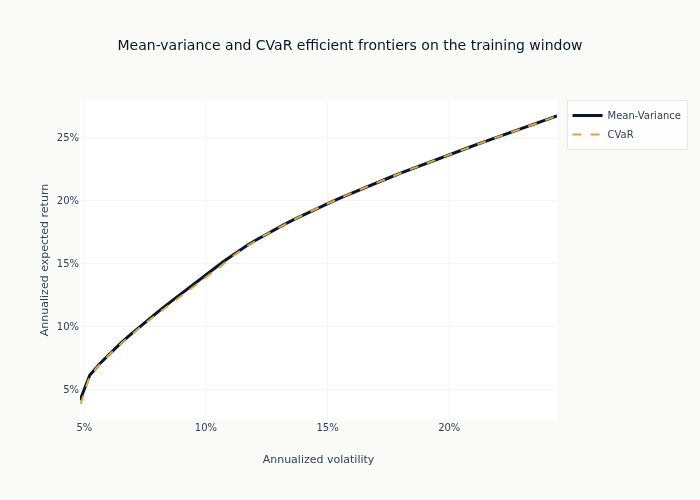

In [26]:
# Plot both efficient frontiers
fig = go.Figure()

fig.add_scatter(
    x=ef_mv["volatility"],
    y=ef_mv["return"],
    mode="lines",
    name="Mean-Variance",
    line=dict(color=COLORS["blue"], width=3),
)

fig.add_scatter(
    x=ef_cvar["volatility"],
    y=ef_cvar["return"],
    mode="lines",
    name="CVaR",
    line=dict(color=COLORS["amber"], width=2, dash="dash"),
)

fig.update_layout(
    title="Mean-variance and CVaR efficient frontiers on the training window",
    xaxis_title="Annualized volatility",
    yaxis_title="Annualized expected return",
    xaxis_tickformat=".0%",
    yaxis_tickformat=".0%",
    height=500,
)
show_plotly_with_alt(
    fig,
    "Two efficient frontiers over the training window, mean-variance and CVaR, annualized volatility against annualized expected return, tracing similar but not identical curves.",
)

The two curves are training diagnostics, not test performance. They show which allocations
each risk definition considers efficient before any later return is observed.

## Part 3: skfolio

skfolio is the newest of the three libraries surveyed here; it exposes a sklearn-style
fit/predict API with built-in cross-validation and hyperparameter tuning.

### Mean-Risk Optimization

skfolio uses sklearn-compatible estimators that can be used in pipelines.

In [27]:
# Max Sharpe with skfolio
model_sharpe = MeanRisk(
    objective_function=ObjectiveFunction.MAXIMIZE_RATIO,
    risk_measure=RiskMeasure.VARIANCE,
    prior_estimator=common_empirical_prior(),
    min_weights=0.0,
    max_weights=1.0,
    budget=1.0,
    risk_free_rate=RISK_FREE_RATE_DAILY,
    solver="CLARABEL",
    save_problem=True,
    raise_on_failure=True,
)
model_sharpe.fit(train_returns)
assert_optimal_status(model_sharpe.problem_, "skfolio Max Sharpe")

skfolio_distribution = model_sharpe.prior_estimator_.return_distribution_
if not np.allclose(skfolio_distribution.mu, common_mean_daily.to_numpy()):
    raise RuntimeError("skfolio expected returns drifted from the common daily estimator.")
if not np.allclose(skfolio_distribution.covariance, common_cov_daily.to_numpy()):
    raise RuntimeError("skfolio covariance drifted from the common daily estimator.")

print(f"skfolio Max Sharpe - Fitted {len(model_sharpe.weights_)} assets")
weights_skfolio_sharpe = align_weights(model_sharpe.weights_, "SKF: Max Sharpe")

skfolio Max Sharpe - Fitted 11 assets


In [28]:
# Min Variance with skfolio
model_minvar = MeanRisk(
    objective_function=ObjectiveFunction.MINIMIZE_RISK,
    risk_measure=RiskMeasure.VARIANCE,
    prior_estimator=common_empirical_prior(),
    min_weights=0.0,
    max_weights=1.0,
    budget=1.0,
    solver="CLARABEL",
    save_problem=True,
    raise_on_failure=True,
)
model_minvar.fit(train_returns)
assert_optimal_status(model_minvar.problem_, "skfolio minimum variance")

weights_skfolio_minvar = align_weights(model_minvar.weights_, "SKF: Min Var")

In [29]:
# CVaR optimization
model_cvar = MeanRisk(
    objective_function=ObjectiveFunction.MINIMIZE_RISK,
    risk_measure=RiskMeasure.CVAR,
    prior_estimator=common_empirical_prior(),
    min_weights=0.0,
    max_weights=1.0,
    budget=1.0,
    cvar_beta=CVAR_CONFIDENCE,
    solver="CLARABEL",
    save_problem=True,
    raise_on_failure=True,
)
model_cvar.fit(train_returns)
assert_optimal_status(model_cvar.problem_, "skfolio minimum CVaR")

weights_skfolio_cvar = align_weights(model_cvar.weights_, "SKF: Min CVaR")

### Independent Common-Objective Checks

The libraries use different parameter units and solver wrappers. These independent
optimizations verify that the boundaries still represent one economic problem.

In [30]:
def negative_common_sharpe(weights: np.ndarray) -> float:
    """Evaluate the shared daily arithmetic excess-return-to-volatility objective."""
    excess_return = weights @ common_mean_daily.to_numpy() - RISK_FREE_RATE_DAILY
    volatility = np.sqrt(weights @ common_cov_daily.to_numpy() @ weights)
    return -float(excess_return / volatility)


common_sharpe_oracle = minimize(
    negative_common_sharpe,
    np.full(num_stocks, 1 / num_stocks),
    method="SLSQP",
    bounds=[(0.0, 1.0)] * num_stocks,
    constraints={"type": "eq", "fun": lambda weights: weights.sum() - 1.0},
    options={"ftol": 1e-13, "maxiter": 2_000},
)
if not common_sharpe_oracle.success:
    raise RuntimeError(f"Independent Max-Sharpe oracle failed: {common_sharpe_oracle.message}")

common_sharpe_weights = {
    "PPO": weights_pypfopt_sharpe,
    "Riskfolio": riskfolio_weights["Standard Deviation"],
    "skfolio": weights_skfolio_sharpe,
}
for library, weights in common_sharpe_weights.items():
    weight_difference = float(np.max(np.abs(weights.to_numpy() - common_sharpe_oracle.x)))
    if weight_difference > COMMON_WEIGHT_TOLERANCE:
        raise RuntimeError(
            f"{library} Max-Sharpe weights differ from the common oracle by "
            f"{weight_difference:.8f}."
        )
    print(f"{library} Max-Sharpe vs independent oracle: {weight_difference:.2e}")

PPO Max-Sharpe vs independent oracle: 3.27e-07
Riskfolio Max-Sharpe vs independent oracle: 3.08e-06
skfolio Max-Sharpe vs independent oracle: 1.69e-05


The matching CVaR task minimizes the historical loss tail at the declared confidence level -
`CVAR_CONFIDENCE` in the settings cell - with long-only weights that sum to one and no return
target or ratio objective.

In [31]:
# Minimum empirical CVaR is a linear program over weights, the VaR threshold, and tail slacks.
training_scenarios = train_returns.to_numpy()
n_scenarios = len(training_scenarios)
tail_coefficient = 1 / ((1 - CVAR_CONFIDENCE) * n_scenarios)
cvar_objective = np.r_[
    np.zeros(num_stocks),
    1.0,
    np.full(n_scenarios, tail_coefficient),
]
cvar_inequality = np.hstack(
    [
        -training_scenarios,
        -np.ones((n_scenarios, 1)),
        -np.eye(n_scenarios),
    ]
)
cvar_oracle = linprog(
    cvar_objective,
    A_ub=cvar_inequality,
    b_ub=np.zeros(n_scenarios),
    A_eq=np.r_[np.ones(num_stocks), np.zeros(1 + n_scenarios)][None, :],
    b_eq=np.array([1.0]),
    bounds=[(0.0, 1.0)] * num_stocks + [(None, None)] + [(0.0, None)] * n_scenarios,
    method="highs",
)
if not cvar_oracle.success:
    raise RuntimeError(f"Independent minimum-CVaR oracle failed: {cvar_oracle.message}")

In [32]:
def empirical_cvar(weights: pd.Series) -> float:
    """Evaluate the same historical-loss CVaR minimized by the independent LP."""
    losses = -(training_scenarios @ weights.to_numpy())
    threshold = np.quantile(losses, CVAR_CONFIDENCE, method="lower")
    return float(threshold + tail_coefficient * np.maximum(losses - threshold, 0).sum())


common_cvar_weights = {
    "PPO": weights_pypfopt_cvar,
    "Riskfolio": riskfolio_weights["Minimum CVaR"],
    "skfolio": weights_skfolio_cvar,
}
for library, weights in common_cvar_weights.items():
    objective_gap = empirical_cvar(weights) - cvar_oracle.fun
    if objective_gap > COMMON_OBJECTIVE_TOLERANCE:
        raise RuntimeError(
            f"{library} minimum-CVaR objective exceeds the common oracle by {objective_gap:.8e}."
        )
    print(f"{library} minimum-CVaR objective gap: {objective_gap:.2e}")

PPO minimum-CVaR objective gap: 1.19e-12
Riskfolio minimum-CVaR objective gap: 2.49e-13
skfolio minimum-CVaR objective gap: 2.03e-13


### Hierarchical Risk Parity

In [33]:
# HRP with skfolio
model_hrp = HierarchicalRiskParity(
    risk_measure=RiskMeasure.VARIANCE,
    distance_estimator=PearsonDistance(),
    hierarchical_clustering_estimator=HierarchicalClustering(linkage_method=LinkageMethod.WARD),
)
model_hrp.fit(train_returns)

weights_skfolio_hrp = align_weights(model_hrp.weights_, "SKF: HRP")

### sklearn Integration: Walk-Forward Cross-Validation

One of skfolio's key advantages is native sklearn compatibility,
including built-in walk-forward and combinatorial purged cross-validation.
Here we apply the same Max-Sharpe feasibility policy before every fold fit.

In [34]:
# Walk-forward cross-validation: one trading year for fitting, then one quarter for validation.
CV_TRAIN_SIZE = 252
CV_TEST_SIZE = 63
cv = WalkForward(train_size=CV_TRAIN_SIZE, test_size=CV_TEST_SIZE)
n_splits = cv.get_n_splits(train_returns)
print(
    f"Training-only walk-forward CV: {n_splits} splits "
    f"({CV_TRAIN_SIZE}d fit / {CV_TEST_SIZE}d validation)"
)
fold_records = []

Training-only walk-forward CV: 11 splits (252d fit / 63d validation)


Feasible folds invoke the unchanged Max-Sharpe estimator and require an exact solver status.
Infeasible folds hold cash at the declared hurdle without calling a ratio solver; the rate
is the one printed in the settings block.

In [35]:
for fold, (train_indices, test_indices) in enumerate(cv.split(train_returns)):
    fold_train = train_returns.iloc[train_indices]
    fold_test = train_returns.iloc[test_indices]
    regime = max_sharpe_regime(fold_train.mean(), RISK_FREE_RATE_DAILY)

    if regime == "cash":
        fold_returns = np.full(len(fold_test), RISK_FREE_RATE_DAILY)
        solver_status = "cash_precheck"
        active_positions = 0
    else:
        fold_model = clone(model_sharpe).fit(fold_train)
        assert_optimal_status(fold_model.problem_, f"skfolio fold {fold} Max Sharpe")
        fold_returns = fold_test.to_numpy() @ fold_model.weights_
        solver_status = fold_model.problem_.status
        active_positions = int((np.abs(fold_model.weights_) > ACTIVE_WEIGHT_THRESHOLD).sum())

    fold_volatility = float(np.std(fold_returns, ddof=1))
    fold_sharpe = (
        None
        if fold_volatility <= np.finfo(float).eps
        else float(
            np.mean(fold_returns - RISK_FREE_RATE_DAILY) / fold_volatility * np.sqrt(TRADING_DAYS)
        )
    )
    fold_records.append(
        {
            "fold": fold,
            "regime": regime,
            "solver_status": solver_status,
            "active_positions": active_positions,
            "annual_return": float(np.mean(fold_returns) * TRADING_DAYS),
            "annual_sharpe": fold_sharpe,
        }
    )

In [36]:
fold_summary = pl.DataFrame(fold_records)
cash_folds = fold_summary.filter(pl.col("regime") == "cash").height
if cash_folds == 0:
    raise RuntimeError("The walk-forward oracle did not exercise the predeclared cash policy.")
print(f"\nWalk-forward regimes: {n_splits - cash_folds} optimized, {cash_folds} cash")
fold_summary


Walk-forward regimes: 10 optimized, 1 cash


fold,regime,solver_status,active_positions,annual_return,annual_sharpe
i64,str,str,i64,f64,f64
0,"""cash""","""cash_precheck""",0,0.04,null
1,"""optimize""","""optimal""",3,0.194185,1.49514
2,"""optimize""","""optimal""",3,0.15258,1.992657
3,"""optimize""","""optimal""",5,0.037314,-0.059543
4,"""optimize""","""optimal""",4,-0.333545,-1.27485
…,…,…,…,…,…
6,"""optimize""","""optimal""",3,0.151477,0.919341
7,"""optimize""","""optimal""",3,0.161873,1.048152
8,"""optimize""","""optimal""",3,-0.209007,-1.856403


This demonstration stays inside the training window. Cash rows are explicit feasibility
decisions at the declared hurdle, while optimized rows expose the solver status and breadth.

In [37]:
portfolios_skf = {
    "Max Sharpe": weights_skfolio_sharpe,
    "Min Variance": weights_skfolio_minvar,
    "Min CVaR": weights_skfolio_cvar,
    "HRP": weights_skfolio_hrp,
}

skfolio_summary = pl.DataFrame(
    [
        {
            "portfolio": name,
            "positions": int((weights.abs() > ACTIVE_WEIGHT_THRESHOLD).sum()),
            "max_weight": float(weights.max()),
        }
        for name, weights in portfolios_skf.items()
    ]
)
skfolio_summary

portfolio,positions,max_weight
str,i64,f64
"""Max Sharpe""",3,0.516813
"""Min Variance""",3,0.922325
"""Min CVaR""",2,0.951775
"""HRP""",11,0.534195


These summary lines are a quick implementation check: if one model keeps producing
extremely concentrated portfolios, it may be using the same objective as the others
but with very different practical behavior.

## Part 4: The fourteen allocations and the equal-weight benchmark on the test window

Every allocation above was fitted on the training panel and is now frozen. Scoring them all
on the same later returns is what separates a difference in objective from a difference in
API: two libraries solving the same problem should land in the same place, and where they do
not, the reason is a different default rather than a different method.

In [38]:
# Collect all portfolio weights
all_portfolios = {
    # PyPortfolioOpt
    "PPO: Max Sharpe": weights_pypfopt_sharpe,
    "PPO: Min Vol": weights_pypfopt_minvol,
    "PPO: Min CVaR": weights_pypfopt_cvar,
    "PPO: HRP": weights_pypfopt_hrp,
    "PPO: Shrinkage": weights_pypfopt_shrunk,
    # Riskfolio-Lib
    "RF: Std Dev": riskfolio_weights["Standard Deviation"],
    "RF: Min CVaR": riskfolio_weights["Minimum CVaR"],
    "RF: Max DD": riskfolio_weights["Max Drawdown"],
    "RF: Conditional DaR": riskfolio_weights["Conditional DaR"],
    "RF: Risk Parity": riskfolio_weights["Risk Parity"],
    # skfolio
    "SKF: Max Sharpe": weights_skfolio_sharpe,
    "SKF: Min Var": weights_skfolio_minvar,
    "SKF: Min CVaR": weights_skfolio_cvar,
    "SKF: HRP": weights_skfolio_hrp,
    # Benchmark
    "Equal Weight": pd.Series(1 / num_stocks, index=tickers),
}

In [39]:
# Compute portfolio returns for each strategy
test_returns_np = test_returns.values
test_dates = test_returns.index.tolist()

portfolio_returns = {}
for name, weights in all_portfolios.items():
    portfolio_returns[name] = test_returns_np @ weights.reindex(tickers).values

### Risk and return over the test window

In [40]:
# Comprehensive evaluation using PortfolioAnalysis
evaluation_results = []

for name, pf_returns in portfolio_returns.items():
    pa = PortfolioAnalysis(
        returns=pl.Series("returns", pf_returns),
        dates=pl.Series("timestamp", test_dates),
        risk_free=RISK_FREE_RATE,
        periods_per_year=TRADING_DAYS,
    )

    metrics = pa.compute_summary_stats()

    evaluation_results.append(
        {
            "portfolio": name,
            "library": name.split(":", maxsplit=1)[0] if ":" in name else "Benchmark",
            "annual_return": metrics.annual_return,
            "annual_volatility": metrics.annual_volatility,
            "sharpe": metrics.sharpe_ratio,
            "sortino": metrics.sortino_ratio,
            "calmar": metrics.calmar_ratio,
            "max_drawdown": metrics.max_drawdown,
            "var_95": metrics.var_95,
            "cvar_95": metrics.cvar_95,
            "win_rate": metrics.win_rate,
        }
    )

eval_df = pl.DataFrame(evaluation_results).sort("sharpe", descending=True)
eval_df

portfolio,library,annual_return,annual_volatility,sharpe,sortino,calmar,max_drawdown,var_95,cvar_95,win_rate
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""RF: Conditional DaR""","""RF""",0.071026,0.135958,0.284117,0.405577,0.279733,-0.253907,-0.014338,-0.018285,0.519126
"""Equal Weight""","""Benchmark""",0.028518,0.119574,-0.033197,-0.047224,0.134272,-0.212387,-0.012462,-0.016189,0.491803
"""PPO: Shrinkage""","""PPO""",0.019637,0.151717,-0.054606,-0.076639,0.063357,-0.309943,-0.015715,-0.02051,0.502732
"""PPO: Max Sharpe""","""PPO""",0.016302,0.151729,-0.076186,-0.106835,0.052311,-0.31163,-0.015701,-0.02048,0.504098
"""RF: Std Dev""","""RF""",0.016301,0.151729,-0.076191,-0.106842,0.052309,-0.31163,-0.015701,-0.02048,0.504098
…,…,…,…,…,…,…,…,…,…,…
"""SKF: Min Var""","""SKF""",-0.011658,0.068001,-0.715317,-0.982001,-0.082076,-0.14204,-0.006763,-0.008924,0.509563
"""PPO: Min Vol""","""PPO""",-0.011677,0.067999,-0.715609,-0.982387,-0.08222,-0.142016,-0.006762,-0.008924,0.509563
"""PPO: Min CVaR""","""PPO""",-0.01477,0.068792,-0.75214,-1.031523,-0.101723,-0.145197,-0.006851,-0.009041,0.504098


These metrics describe frozen allocations on later returns. They support comparison of
implementations, and one historical test is not grounds for choosing an implementation
permanently.

### What one of them costs to hold

Vectorized matrix multiplication is useful for comparing optimizers under identical assumptions.
To connect this to deployable execution, replay one optimized portfolio through Engine.

The bridge strategy restores the same frozen target each day. The engine then adds
next-bar timing, slippage, and commissions without changing the allocation policy.

In [41]:
class DailyTargetWeightStrategy(Strategy):
    def __init__(self, target_weights: dict[str, float], allow_short: bool):
        self.target_weights = target_weights
        self.executor = TargetWeightExecutor(
            config=RebalanceConfig(
                min_trade_value=0.0,
                min_weight_change=0.0,
                allow_fractional=True,
                allow_short=allow_short,
            )
        )

    def on_data(self, timestamp, data, context, broker):
        targets = {asset: weight for asset, weight in self.target_weights.items() if asset in data}
        if targets:
            self.executor.execute(targets, data, broker)

In [42]:
# Build engine inputs from the selected library portfolio and the price panel.
bridge_name = "PPO: Max Sharpe"
engine_target_weights = {
    ticker: float(weight)
    for ticker, weight in all_portfolios[bridge_name].items()
    if abs(float(weight)) > 1e-8
}
allow_short_engine = any(weight < 0 for weight in engine_target_weights.values())

test_prices_long = (
    etf_data.filter(pl.col("timestamp") > pl.lit(TRAIN_END).str.to_date())
    .select(["timestamp", "symbol", "open", "high", "low", "close", "volume"])
    .drop_nulls()
    .with_columns(pl.col("timestamp").cast(pl.Datetime("us")))
    .sort(["timestamp", "symbol"])
)

In [43]:
# Run the execution-aware simulation and collect daily returns.
engine = Engine(
    feed=DataFeed(prices_df=test_prices_long),
    strategy=DailyTargetWeightStrategy(engine_target_weights, allow_short=allow_short_engine),
    config=BacktestConfig(
        initial_cash=100_000.0,
        execution_mode=ExecutionMode.NEXT_BAR,
        commission_type=CommissionType.PERCENTAGE,
        commission_rate=COMMISSION_RATE,
        slippage_type=SlippageType.PERCENTAGE,
        slippage_rate=SLIPPAGE_RATE,
        allow_short_selling=allow_short_engine,
    ),
)

engine_daily = (
    engine.run()
    .to_daily_pnl()
    .select(
        pl.col("date").cast(pl.Datetime("us")).alias("timestamp"),
        pl.col("return_pct").alias("engine_return"),
    )
)
# NEXT_BAR cannot hold the target during the first test return. Exclude that warm-up
# observation from both paths, then require an identical one-to-one scored date set.
warmup_timestamp = pl.Series("timestamp", [test_dates[0]]).cast(pl.Datetime("us")).item()
vectorized_daily = pl.DataFrame(
    {
        "timestamp": pl.Series(test_dates[1:]).cast(pl.Datetime("us")),
        "vectorized_return": portfolio_returns[bridge_name][1:],
    }
)
engine_scored = engine_daily.filter(pl.col("timestamp") > warmup_timestamp).sort("timestamp")

if engine_scored["timestamp"].to_list() != vectorized_daily["timestamp"].to_list():
    raise RuntimeError("Engine and vectorized bridge do not contain identical scored bars.")

In [44]:
# Compare vectorized and engine results on the asserted common date set.
bridge = (
    vectorized_daily.join(engine_scored, on="timestamp", how="inner", validate="1:1")
    .drop_nulls(["vectorized_return", "engine_return"])
    .sort("timestamp")
)
if bridge.height != len(test_dates) - 1:
    raise RuntimeError("Execution bridge lost rows after the matched-bar assertion.")

vec_pa = PortfolioAnalysis(
    returns=bridge["vectorized_return"],
    dates=bridge["timestamp"],
    risk_free=RISK_FREE_RATE,
    periods_per_year=TRADING_DAYS,
)
eng_pa = PortfolioAnalysis(
    returns=bridge["engine_return"],
    dates=bridge["timestamp"],
    risk_free=RISK_FREE_RATE,
    periods_per_year=TRADING_DAYS,
)
vec_stats = vec_pa.compute_summary_stats()
eng_stats = eng_pa.compute_summary_stats()

print(f"Execution bridge ({bridge_name}):")
print(
    f"  Matched bars={bridge.height}, "
    f"window={bridge['timestamp'].min().date()} to {bridge['timestamp'].max().date()}"
)
print(
    f"  Vectorized Sharpe={vec_stats.sharpe_ratio:.3f}, Engine Sharpe={eng_stats.sharpe_ratio:.3f}"
)
print(f"  Vectorized MaxDD={vec_stats.max_drawdown:.2%}, Engine MaxDD={eng_stats.max_drawdown:.2%}")

Execution bridge (PPO: Max Sharpe):
  Matched bars=731, window=2022-01-04 to 2024-11-29
  Vectorized Sharpe=-0.060, Engine Sharpe=-0.075
  Vectorized MaxDD=-30.62%, Engine MaxDD=-30.80%


The first test return is an explicit NEXT_BAR warm-up and is absent from both scored paths.
Every reported bridge observation therefore has prior target exposure in the vectorized and
Engine paths; any remaining gap reflects fills and declared costs on identical bars.

### Growth paths of the comparable implementations

The growth chart focuses on the comparable Max-Sharpe implementations and an equal-weight
benchmark. Showing four lines preserves the cross-library comparison without a fifteen-line
legend obscuring the evidence.

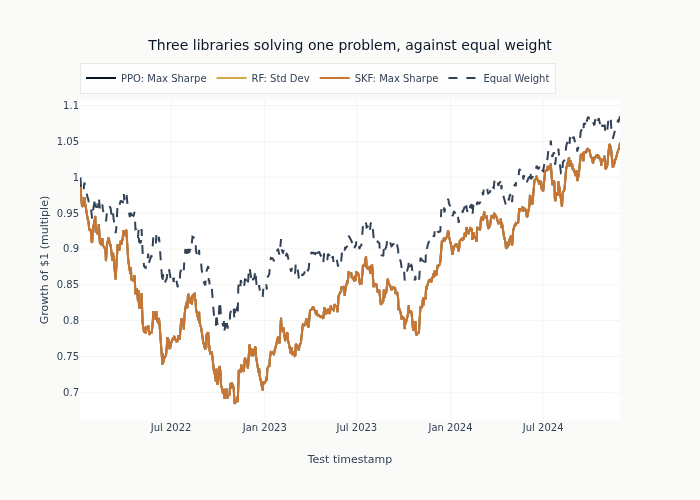

In [45]:
growth_methods = ["PPO: Max Sharpe", "RF: Std Dev", "SKF: Max Sharpe", "Equal Weight"]
growth_colors = {
    "PPO: Max Sharpe": COLORS["blue"],
    "RF: Std Dev": COLORS["amber"],
    "SKF: Max Sharpe": COLORS["copper"],
    "Equal Weight": COLORS["neutral"],
}
cumulative_growth = {name: np.cumprod(1 + portfolio_returns[name]) for name in growth_methods}

fig = go.Figure()
for name in growth_methods:
    fig.add_scatter(
        # datetime64 rather than the index's pandas Timestamps: the static-image writer that
        # renders this figure alongside the interactive one cannot serialize a Timestamp.
        x=np.asarray(test_dates, dtype="datetime64[ns]"),
        y=cumulative_growth[name],
        mode="lines",
        name=name,
        line=dict(
            color=growth_colors[name],
            # The benchmark is drawn as context, so it is the dashed neutral line and the
            # three optimized paths are weighted alike - none of them is the subject.
            width=2,
            dash="dash" if name == "Equal Weight" else "solid",
        ),
    )

fig.update_layout(
    title="Three libraries solving one problem, against equal weight",
    xaxis_title="Test timestamp",
    yaxis_title="Growth of $1 (multiple)",
    height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
)
show_plotly_with_alt(
    fig,
    "Four growth-of-one-dollar paths over the test window: the three libraries' "
    "maximum-Sharpe allocations lie on top of one another so only the last drawn is "
    "visible, and the dashed equal-weight benchmark runs above them for most of the window.",
)

The risk-return map retains every configuration but uses color only for library identity.
Hover labels carry the optimizer name, avoiding a fifteen-color legend.

Highest test Sharpe: RF: Conditional DaR at 0.284, annualized return 7.1% at 13.6% volatility


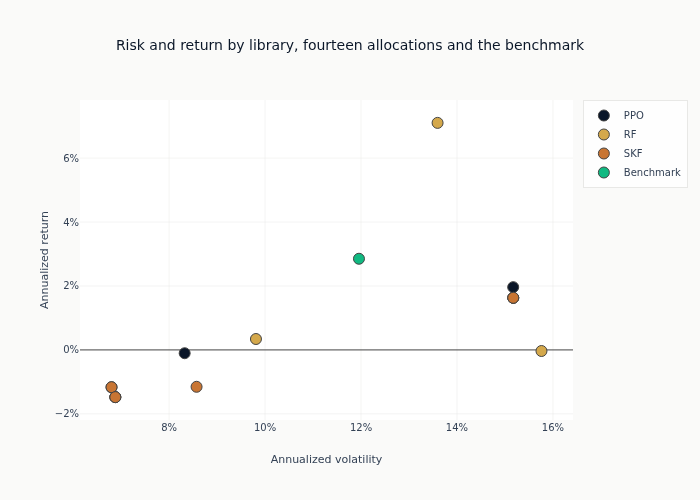

In [46]:
eval_pd = eval_df.to_pandas()
library_order = ["PPO", "RF", "SKF", "Benchmark"]
library_colors = dict(zip(library_order, ml4t_palette(4, categorical=True), strict=True))
top_row = eval_df.row(0, named=True)
print(
    f"Highest test Sharpe: {top_row['portfolio']} at {top_row['sharpe']:.3f}, "
    f"annualized return {top_row['annual_return']:.1%} at {top_row['annual_volatility']:.1%} "
    "volatility"
)

fig = go.Figure()
for library in library_order:
    subset = eval_pd.loc[eval_pd["library"] == library]
    fig.add_scatter(
        x=subset["annual_volatility"],
        y=subset["annual_return"],
        mode="markers",
        name=library,
        text=subset["portfolio"],
        customdata=subset[["sharpe", "max_drawdown"]],
        marker=dict(color=library_colors[library], size=11, line=dict(width=1)),
        hovertemplate=(
            "%{text}<br>Annual return=%{y:.1%}<br>Annual volatility=%{x:.1%}"
            "<br>Sharpe=%{customdata[0]:.2f}<br>Max drawdown=%{customdata[1]:.1%}<extra></extra>"
        ),
    )

fig.update_layout(
    title="Risk and return by library, fourteen allocations and the benchmark",
    xaxis_title="Annualized volatility",
    yaxis_title="Annualized return",
    xaxis_tickformat=".0%",
    yaxis_tickformat=".0%",
    height=500,
)
show_plotly_with_alt(
    fig,
    "Scatter of fourteen frozen allocations plus the equal-weight benchmark, annualized volatility against annualized return, coloured by library, with several points from different libraries falling on top of each other.",
)

Overlapping points reveal when API choice matters less than objective choice. The chart reports
a historical test, while the training-only walk-forward exercise provides the stability context.

A rank heatmap compares unlike metrics without pretending their raw scales are commensurate.
Higher ranks are better for every displayed column, including less-negative loss measures.

Highest and lowest mean rank across the five metrics:
  RF: Conditional DaR: 11.4
  SKF: Min CVaR: 5.4


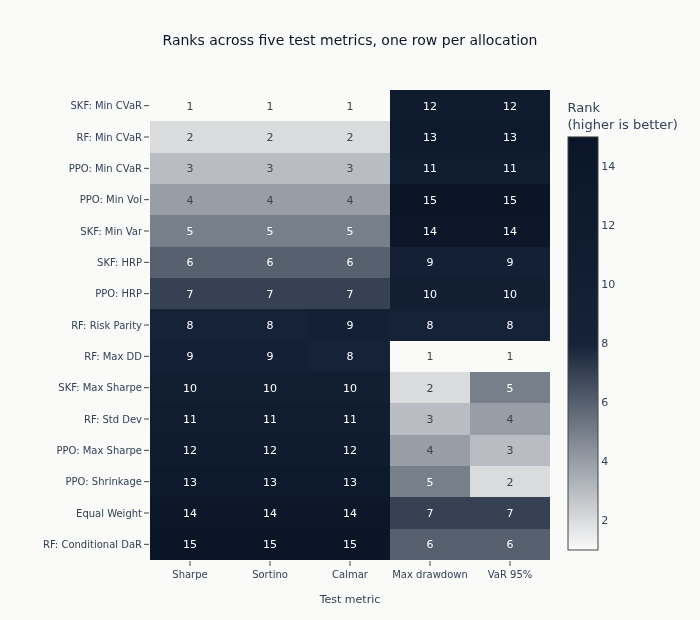

In [47]:
metrics_cols = ["sharpe", "sortino", "calmar", "max_drawdown", "var_95"]
metric_labels = ["Sharpe", "Sortino", "Calmar", "Max drawdown", "VaR 95%"]
heatmap_data = eval_pd.set_index("portfolio")[metrics_cols]
ranked = heatmap_data.rank(axis=0)
mean_rank = ranked.mean(axis=1).sort_values(ascending=False)
print("Highest and lowest mean rank across the five metrics:")
print(f"  {mean_rank.index[0]}: {mean_rank.iloc[0]:.1f}")
print(f"  {mean_rank.index[-1]}: {mean_rank.iloc[-1]:.1f}")

fig = go.Figure(
    data=go.Heatmap(
        z=ranked.values,
        x=metric_labels,
        y=ranked.index,
        text=np.rint(ranked.values).astype(int),
        texttemplate="%{text}",
        colorscale=[
            [0, COLORS["bg_light"]],
            [0.5, COLORS["blue_light"]],
            [1, COLORS["blue"]],
        ],
        zmin=1,
        zmax=len(ranked),
        colorbar=dict(title="Rank<br>(higher is better)"),
        hovertemplate="%{y}<br>%{x}: rank %{z:.0f}<extra></extra>",
    )
)
fig.update_layout(
    title="Ranks across five test metrics, one row per allocation",
    xaxis_title="Test metric",
    height=620,
    margin=dict(l=150, r=80, t=90, b=60),
)
show_plotly_with_alt(
    fig,
    "Heatmap of rank across five test metrics, one row per allocation and one column per metric, each cell labelled with its rank and shaded so higher ranks are darker.",
)

An allocation ranking mid-table on every column is a different thing from one ranking first
on a single column and last elsewhere, and the heatmap is where that shows. It remains a
diagnostic of this test period rather than a second selection stage.

### Weight Distribution Comparison

In [48]:
concentration_stats = []

for name, weights in all_portfolios.items():
    values = weights.reindex(tickers).to_numpy()
    n_positions = int((np.abs(values) > ACTIVE_WEIGHT_THRESHOLD).sum())
    max_weight = float(np.max(values))
    top5_weight = float(np.sort(values)[-5:].sum())
    hhi = float((values**2).sum())

    concentration_stats.append(
        {
            "portfolio": name,
            "positions": n_positions,
            "max_weight": max_weight,
            "top5_weight": top5_weight,
            "hhi": hhi,
        }
    )

conc_df = pl.DataFrame(concentration_stats).sort("hhi", descending=True)
conc_df

portfolio,positions,max_weight,top5_weight,hhi
str,i64,f64,f64,f64
"""SKF: Min CVaR""",2,0.951775,1.0,0.9082
"""PPO: Min CVaR""",2,0.951775,1.0,0.9082
"""RF: Min CVaR""",2,0.951775,1.0,0.9082
"""PPO: Min Vol""",3,0.922442,1.0,0.8549
"""SKF: Min Var""",3,0.922325,0.999981,0.854676
…,…,…,…,…
"""RF: Conditional DaR""",3,0.44519,1.0,0.361999
"""SKF: HRP""",11,0.534195,0.86363,0.321058
"""PPO: HRP""",11,0.50939,0.86822,0.300096


HHI turns visual concentration into a comparable statistic. A value near the equal-weight
reference indicates broad diversification; larger values expose greater single-name dependence.

### How much each allocation depends on one name

In [49]:
fig = make_subplots(
    rows=1,
    cols=2,
    shared_yaxes=True,
    horizontal_spacing=0.08,
    subplot_titles=["Active positions", "Herfindahl-Hirschman index"],
)
portfolios = conc_df["portfolio"].to_list()
equal_weight_hhi = 1 / num_stocks
least_concentrated = (
    conc_df.filter(pl.col("portfolio") != "Equal Weight").sort("hhi").row(0, named=True)
)
print(
    f"Across {num_stocks} funds, no long-only fully-invested portfolio can have an HHI below "
    f"equal weight's {equal_weight_hhi:.3f}. The least concentrated optimized allocation is "
    f"{least_concentrated['portfolio']} at {least_concentrated['hhi']:.3f}, holding "
    f"{least_concentrated['positions']} positions."
)

Across 11 funds, no long-only fully-invested portfolio can have an HHI below equal weight's 0.091. The least concentrated optimized allocation is RF: Risk Parity at 0.134, holding 11 positions.


Horizontal bars keep all portfolio labels readable. The second panel adds the equal-weight
HHI as a reference rather than treating the benchmark as another optimized method.

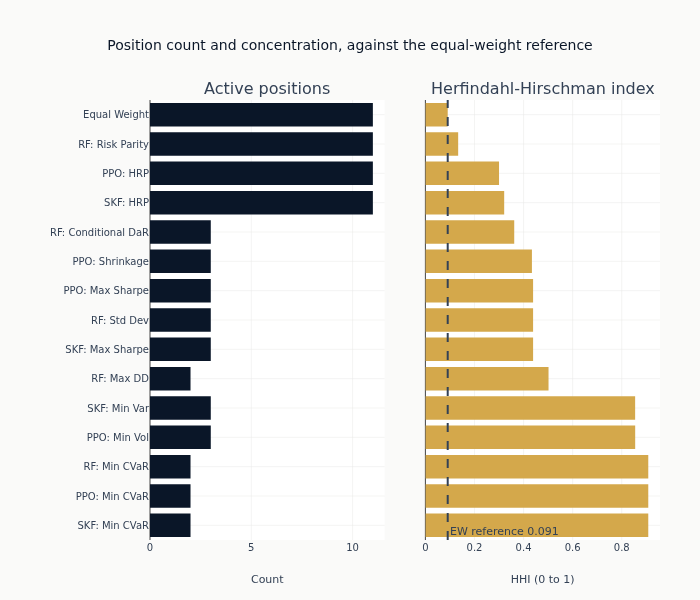

In [50]:
fig.add_bar(
    x=conc_df["positions"].to_list(),
    y=portfolios,
    orientation="h",
    name="Positions",
    marker_color=COLORS["blue"],
    row=1,
    col=1,
)

fig.add_bar(
    x=conc_df["hhi"].to_list(),
    y=portfolios,
    orientation="h",
    name="HHI",
    marker_color=COLORS["amber"],
    row=1,
    col=2,
)

fig.add_vline(
    x=equal_weight_hhi,
    line_dash="dash",
    line_color=COLORS["neutral"],
    annotation_text=f"EW reference {equal_weight_hhi:.3f}",
    annotation_position="bottom right",
    row=1,
    col=2,
)

fig.update_layout(
    title="Position count and concentration, against the equal-weight reference",
    height=600,
    showlegend=False,
    margin=dict(l=150, r=40, t=100, b=60),
)
fig.update_xaxes(title_text="Count", row=1, col=1, rangemode="tozero")
fig.update_xaxes(title_text="HHI (0 to 1)", row=1, col=2, rangemode="tozero")
show_plotly_with_alt(
    fig,
    "Two horizontal-bar panels, one row per allocation: active position count on the left and the Herfindahl-Hirschman index on the right, with a dashed line marking the equal-weight index.",
)

## Part 5: Practical Considerations

PyPortfolioOpt exposes objective penalties directly. Comparing two matched pairs shows how a
turnover penalty changes trading distance and how L2 regularization changes Max-Sharpe breadth.
The library warns that this deliberate objective combination uses its transformed formulation;
only that exact warning is scoped to the regularized call below.

In [51]:
ef = EfficientFrontier(mu, S)
initial_weights = np.full(num_stocks, 1 / num_stocks)
ef.add_objective(
    objective_functions.transaction_cost,
    w_prev=initial_weights,
    k=TRANSACTION_COST_PENALTY,
)
weights_with_cost = align_weights(ef.min_volatility(), "PPO: Min Vol with turnover penalty")
assert_optimal_status(ef._opt, "PPO minimum volatility with turnover penalty")

ef_no_cost = EfficientFrontier(mu, S)
weights_no_cost = align_weights(ef_no_cost.min_volatility(), "PPO: Min Vol without penalty")
assert_optimal_status(ef_no_cost._opt, "PPO minimum volatility without penalty")

turnover_with = np.abs(weights_with_cost.values - initial_weights).sum()
turnover_without = np.abs(weights_no_cost.values - initial_weights).sum()
turnover_reduction = 1 - turnover_with / turnover_without

ef_sharpe_unregularized = EfficientFrontier(mu, S)
weights_sharpe_unregularized = align_weights(
    ef_sharpe_unregularized.max_sharpe(risk_free_rate=RISK_FREE_RATE),
    "PPO: Unregularized Max Sharpe",
)
assert_optimal_status(ef_sharpe_unregularized._opt, "PPO unregularized Max Sharpe")

ef_reg = EfficientFrontier(mu, S)
ef_reg.add_objective(objective_functions.L2_reg, gamma=L2_GAMMA)
with suppress_ppo_max_sharpe_objective_warning():
    weights_regularized = align_weights(
        ef_reg.max_sharpe(risk_free_rate=RISK_FREE_RATE),
        "PPO: Regularized Max Sharpe",
    )
assert_optimal_status(ef_reg._opt, "PPO regularized Max Sharpe")
unregularized_positions = int((weights_sharpe_unregularized > ACTIVE_WEIGHT_THRESHOLD).sum())
regularized_positions = int((weights_regularized > ACTIVE_WEIGHT_THRESHOLD).sum())

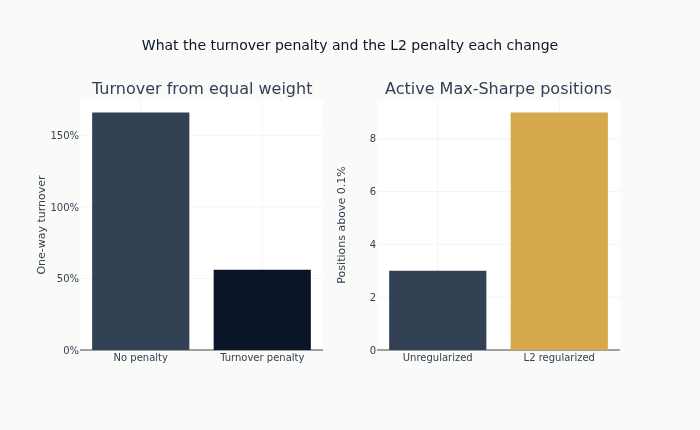

In [52]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Turnover from equal weight", "Active Max-Sharpe positions"],
)
fig.add_bar(
    x=["No penalty", "Turnover penalty"],
    y=[turnover_without, turnover_with],
    marker_color=[COLORS["neutral"], COLORS["blue"]],
    showlegend=False,
    row=1,
    col=1,
)
fig.add_bar(
    x=["Unregularized", "L2 regularized"],
    y=[unregularized_positions, regularized_positions],
    marker_color=[COLORS["neutral"], COLORS["amber"]],
    showlegend=False,
    row=1,
    col=2,
)
fig.update_layout(
    title="What the turnover penalty and the L2 penalty each change",
    height=430,
)
fig.update_yaxes(title_text="One-way turnover", tickformat=".0%", rangemode="tozero", row=1, col=1)
fig.update_yaxes(
    title_text=f"Positions above {ACTIVE_WEIGHT_THRESHOLD:.1%}",
    rangemode="tozero",
    row=1,
    col=2,
)
show_plotly_with_alt(
    fig,
    "Two bar panels: one-way turnover from equal weight with and without the turnover penalty, and the active position count of the maximum-Sharpe solution with and without L2 regularization.",
)

## API Ergonomics Comparison

Using all three libraries on the same training and test windows reveals different workflow
strengths without treating a one-period ranking as permanent:

**PyPortfolioOpt** has the most intuitive API for standard tasks. Creating an
`EfficientFrontier`, calling `max_sharpe()`, and inspecting `portfolio_performance()`
requires minimal boilerplate. Its built-in objective penalties make turnover and
regularization experiments explicit.

**Riskfolio-Lib** exposes multiple risk families through a single `Portfolio` object.
The `optimization()` method
accepts string codes for risk measures (`"MV"`, `"CVaR"`, `"MDD"`), making it easy
to sweep across objectives programmatically and compare training frontiers.

**skfolio** stands out for ML integration. Models are sklearn estimators with `fit()` /
`predict()` semantics, meaning they slot into `Pipeline`, `GridSearchCV`, and
walk-forward cross-validation without adapters. This is a decisive advantage when
portfolio construction is one stage in a larger ML workflow.

| Criterion | PyPortfolioOpt | Riskfolio-Lib | skfolio |
|-----------|----------------|---------------|---------|
| Optimizer-object workflow | Native | Portfolio object | Estimator object |
| Multiple risk families | Selected classes | Unified interface | Selected estimators |
| ML pipeline integration | Manual | Manual | Native sklearn style |
| Cross-validation | Manual | Manual | Built-in (WalkForward, CPCV) |
| Objective penalties | Native | Via model settings | Via constraints/settings |

## What the four comparisons produced

Four numbers close the notebook, and each one answers a question the sections above set up.

In [53]:
ppo_test_sharpe = float(eval_df.filter(pl.col("portfolio") == "PPO: Max Sharpe")["sharpe"].item())
skfolio_test_sharpe = float(
    eval_df.filter(pl.col("portfolio") == "SKF: Max Sharpe")["sharpe"].item()
)
max_sharpe_test_gap = abs(ppo_test_sharpe - skfolio_test_sharpe)
print("Two libraries, one Max-Sharpe problem, frozen test window:")
print(f"  PyPortfolioOpt {ppo_test_sharpe:.6f}   skfolio {skfolio_test_sharpe:.6f}")
print(f"  absolute gap   {max_sharpe_test_gap:.6f}")
print("\nThe same allocation, vectorized and through the engine:")
print(
    f"  Sharpe {vec_stats.sharpe_ratio:.3f} -> {eng_stats.sharpe_ratio:.3f} at "
    f"{COMMISSION_RATE * 1e4:.0f} bp commission and {SLIPPAGE_RATE * 1e4:.0f} bp slippage"
)
print("\nWhat the two declared penalties change:")
print(f"  turnover penalty: one-way trading distance {turnover_without:.1%} -> {turnover_with:.1%}")
print(
    f"  L2 penalty of {L2_GAMMA:.1f}: active positions "
    f"{unregularized_positions} -> {regularized_positions}"
)

Two libraries, one Max-Sharpe problem, frozen test window:
  PyPortfolioOpt -0.076186   skfolio -0.076197
  absolute gap   0.000011

The same allocation, vectorized and through the engine:
  Sharpe -0.060 -> -0.075 at 5 bp commission and 5 bp slippage

What the two declared penalties change:
  turnover penalty: one-way trading distance 166.3% -> 56.2%
  L2 penalty of 0.5: active positions 3 -> 9


In [54]:
display(
    Markdown(
        "PyPortfolioOpt and skfolio, given the same moments, the same hurdle and the same "
        "long-only budget constraint, land within "
        f"**{max_sharpe_test_gap:.6f}** of each other on the test Sharpe ratio."
    )
)

PyPortfolioOpt and skfolio, given the same moments, the same hurdle and the same long-only budget constraint, land within **0.000011** of each other on the test Sharpe ratio.

The first pair is the one the notebook is built to produce, and the gap between the two
libraries is agreement to solver tolerance rather than to the digit. That is the point: the API
is not the method, and where two of these libraries differ materially on a problem, it is
because a default differs, not because the mathematics does.

The other three are about what the comparison leaves out. Routing one allocation through an
execution engine moves its Sharpe ratio, and the move is execution timing, fills and costs
together: the engine fills on the next bar, so matching the scored dates does not make its
exposures identical to the vectorized calculation. Isolating the declared commission and slippage
would take two otherwise identical engine runs, one at zero cost. The turnover penalty cuts
trading distance, and the L2 penalty widens the number of positions held - both are objective
terms, so both are choices a reader makes rather than properties of a library.

## Key takeaways

1. **The same objective solved by three APIs is one problem, and the check is arithmetic.**
   Estimate the moments once, convert at each library's boundary, and matched objectives agree
   to solver tolerance. A gap larger than that is a difference in defaults worth finding.
2. **What differs between these libraries is workflow, not answers.** Optimizer objects, a
   single portfolio object spanning many risk measures, and sklearn estimators that drop into a
   pipeline solve different research problems. Which fits depends on what surrounds the
   allocation step.
3. **A penalty is part of the objective, and changes the answer.** Turnover and L2
   regularization change the answer, and a library that exposes them makes an explicit choice
   out of what would otherwise be an implicit one.
4. **Concentration needs a number.** The Herfindahl index turns "this looks concentrated" into
   something comparable across fourteen allocations and against an equal-weight reference.
5. **A ranking on one test window is a description of that window.** Every allocation here is
   frozen and scored once; nothing was re-tuned against the result, and nothing here estimates
   how the ordering would change on a different split.

### Known limitations

- One training window, one test window, one fixed universe assembled from funds that exist
  today. A different split date would refit all fourteen allocations.
- The library versions are the ones pinned in the `ml4t` image. Breadth and defaults change
  between releases, and the workflow comparison is the part of this that ages best.
- Only one of the fourteen allocations is put through the execution engine. The others are
  compared gross of costs, so the table ranks paper portfolios.
- The walk-forward cross-validation runs inside the training window as a stability
  demonstration. Each fold's validation observations are held out from that fold's own fit, but
  they are not an additional independent test set: every one of them sits inside the training
  window, and the test window below was never touched by it.

**Next**: [`09_allocator_comparison`](09_allocator_comparison.ipynb) extends the comparison
with explicit estimation-risk controls.

**Book**: Section 17.7 develops the controlled allocator comparison framework.